# Plot Results

## Box Plot Overview

### ML

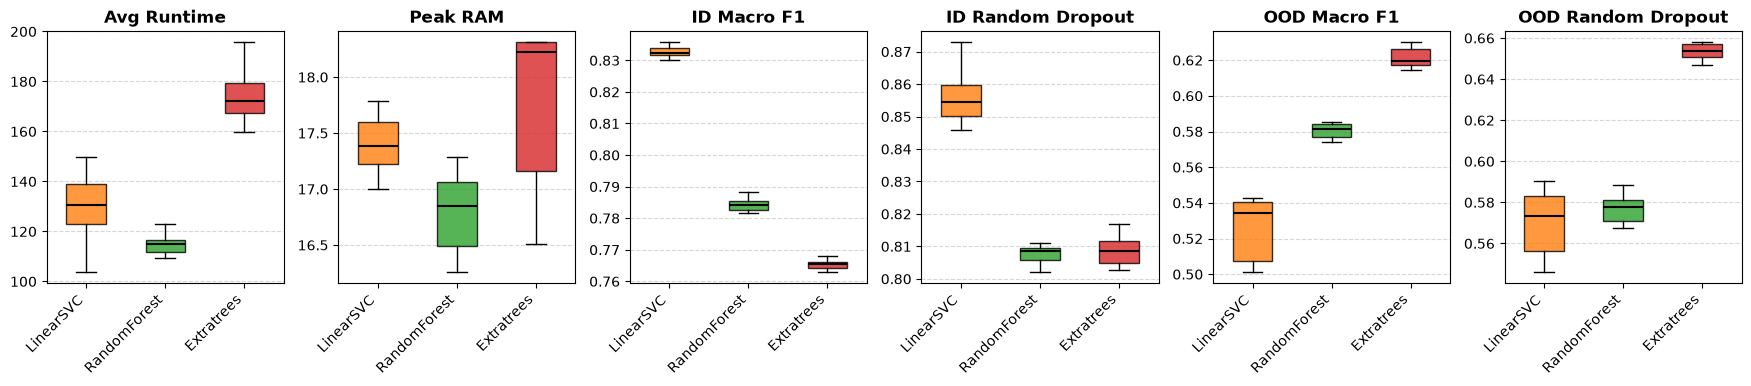

In [6]:
# temporary only with rf, linsvc and extratrees
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'Out-of-Distribution']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
logisticregression_csv_file = '../training/results/new2/logisticregression/combined_results.csv'
linearsvc_csv_file = '../training/results/new2/linearsvc/combined_result.csv'
randomforest_csv_file = '../training/results/new2/randomforest/combined_result.csv'
extratrees_csv_file = '../training/results/new2/extratrees/combined_results.csv'
lightgbm_csv_file = '../training/results/new2/lightgbm/combined_results.csv'

subplot_titles = ['Avg Runtime', 'Peak RAM', 'ID Macro F1', 'ID Random Dropout', 'OOD Macro F1', 'OOD Random Dropout']

runs_model2 = extract_table_metrics_from_csv(linearsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(randomforest_csv_file)
runs_model4 = extract_table_metrics_from_csv(extratrees_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['LinearSVC', 'RandomForest', 'Extratrees',]
colors = ['#ff7f0e', '#2ca02c', '#d62728']

# Erstelle ein 2x4 Grid mit unabhängigen Y-Achsen (sharey=False)
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), sharey=False)
axes = axes.flatten()  # Macht aus dem 2D-Array der Axes ein 1D-Array für leichteres Iterieren

for i, metric in enumerate(subplot_titles):
    ax = axes[i]
    
    # Die Daten der 4 Modelle für genau diesen einen Zelltyp zusammenstellen
    metric_data = [
        runs_model2[i],
        runs_model3[i],
        runs_model4[i]
    ]
    
    # Boxplot für diesen Zelltyp zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben aus der Liste anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        
    # Mediane schwarz markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Subplot-Design
    ax.set_title(subplot_titles[i], fontsize=12, weight='bold')
    
    # Beschriftung der X-Achse (Modellnamen um 45 Grad gedreht für Platz)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    
    # Y-Achse intelligent limitieren (Maximal 1.05, Minimum passt sich den Daten an)
    if "F1" in metric or "Dropout" in metric:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Globale Titel und Achsenbeschriftung
#fig.suptitle('Overview of Performance of Reference Models over 10 Runs', fontsize=18, weight='bold')
#fig.text(0.01, 0.5, 'F1-Score', va='center', rotation='vertical', fontsize=14, weight='bold')

# Layout bereinigen
plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

plt.savefig('figures/ml_table_metrics_box_plot.png')
plt.show()

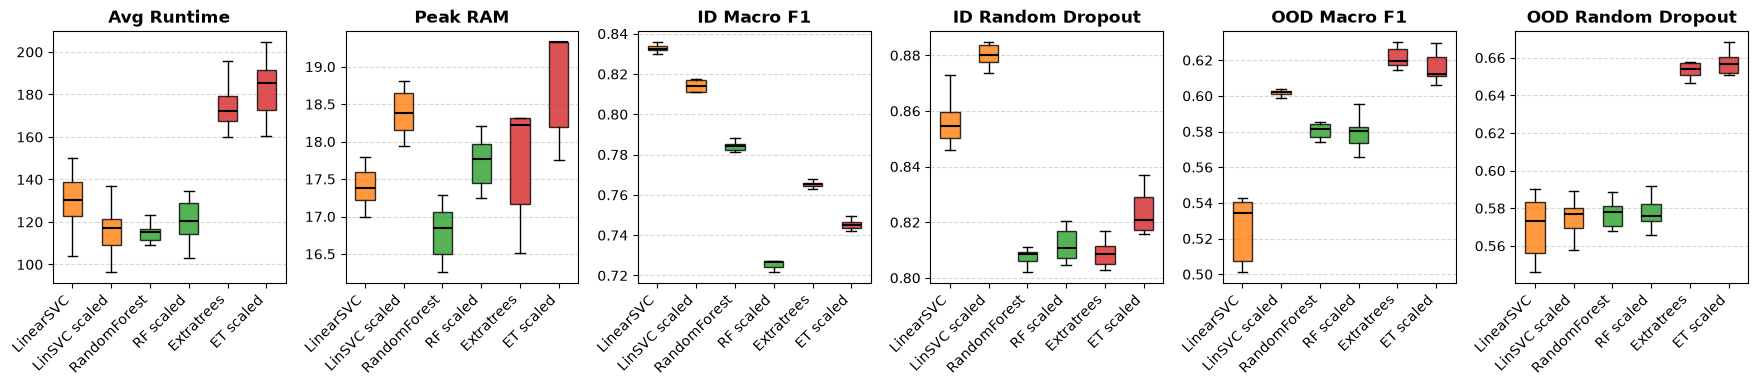

In [10]:
# temporary only with rf, linsvc and extratrees; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'Out-of-Distribution']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
logisticregression_csv_file = '../training/results/new2/logisticregression/combined_results.csv'
linearsvc_csv_file = '../training/results/new2/linearsvc/combined_result.csv'
randomforest_csv_file = '../training/results/new2/randomforest/combined_result.csv'
extratrees_csv_file = '../training/results/new2/extratrees/combined_results.csv'
lightgbm_csv_file = '../training/results/new2/lightgbm/combined_results.csv'

logisticregression_scaled_csv_file = '../training/results/new2/logisticregression_scaled/combined_results.csv'
linearsvc_scaled_csv_file = '../training/results/new2/linearsvc_scaled/combined_result.csv'
randomforest_scaled_csv_file = '../training/results/new2/randomforest_scaled/combined_result.csv'
extratrees_scaled_csv_file = '../training/results/new2/extratrees_scaled/combined_results.csv'
lightgbm_scaled_csv_file = '../training/results/new2/lightgbm_scaled/combined_results.csv'

subplot_titles = ['Avg Runtime', 'Peak RAM', 'ID Macro F1', 'ID Random Dropout', 'OOD Macro F1', 'OOD Random Dropout']

runs_model2 = extract_table_metrics_from_csv(linearsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(randomforest_csv_file)
runs_model4 = extract_table_metrics_from_csv(extratrees_csv_file)

runs_model21 = extract_table_metrics_from_csv(linearsvc_scaled_csv_file)
runs_model31 = extract_table_metrics_from_csv(randomforest_scaled_csv_file)
runs_model41 = extract_table_metrics_from_csv(extratrees_scaled_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['LinearSVC', 'LinSVC scaled', 'RandomForest', 'RF scaled', 'Extratrees', 'ET scaled']
colors = ['#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728']

# Erstelle ein 2x4 Grid mit unabhängigen Y-Achsen (sharey=False)
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), sharey=False)
axes = axes.flatten()  # Macht aus dem 2D-Array der Axes ein 1D-Array für leichteres Iterieren

for i, metric in enumerate(subplot_titles):
    ax = axes[i]
    
    # Die Daten der 4 Modelle für genau diesen einen Zelltyp zusammenstellen
    metric_data = [
        runs_model2[i],
        runs_model21[i],
        runs_model3[i],
        runs_model31[i],
        runs_model4[i],
        runs_model41[i]
    ]
    
    # Boxplot für diesen Zelltyp zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben aus der Liste anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        
    # Mediane schwarz markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Subplot-Design
    ax.set_title(subplot_titles[i], fontsize=12, weight='bold')
    
    # Beschriftung der X-Achse (Modellnamen um 45 Grad gedreht für Platz)
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    
    # Y-Achse intelligent limitieren (Maximal 1.05, Minimum passt sich den Daten an)
    if "F1" in metric or "Dropout" in metric:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Globale Titel und Achsenbeschriftung
#fig.suptitle('Overview of Performance of Reference Models over 10 Runs', fontsize=18, weight='bold')
#fig.text(0.01, 0.5, 'F1-Score', va='center', rotation='vertical', fontsize=14, weight='bold')

# Layout bereinigen
plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

plt.savefig('figures/ml_scaled_comparison_table_metrics_box_plot.png')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'Out-of-Distribution']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
logisticregression_csv_file = '../training/results/new2/logisticregression/combined_results.csv'
linearsvc_csv_file = '../training/results/new2/linearsvc/combined_result.csv'
randomforest_csv_file = '../training/results/new2/randomforest/combined_result.csv'
extratrees_csv_file = '../training/results/new2/extratrees/combined_results.csv'
lightgbm_csv_file = '../training/results/new2/lightgbm/combined_results.csv'

subplot_titles = ['Avg Runtime', 'Peak RAM', 'ID Macro F1', 'ID Random Dropout', 'OOD Macro F1', 'OOD Random Dropout']

runs_model1 = extract_table_metrics_from_csv(logisticregression_csv_file)
runs_model2 = extract_table_metrics_from_csv(linearsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(randomforest_csv_file)
runs_model4 = extract_table_metrics_from_csv(extratrees_csv_file)
runs_model5 = extract_table_metrics_from_csv(lightgbm_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['LogisticRegression', 'LinearSVC', 'RandomForest', 'Extratrees', 'Lightgbm']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#b62728']

# Erstelle ein 2x4 Grid mit unabhängigen Y-Achsen (sharey=False)
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), sharey=False)
axes = axes.flatten()  # Macht aus dem 2D-Array der Axes ein 1D-Array für leichteres Iterieren

for i, metric in enumerate(subplot_titles):
    ax = axes[i]
    
    # Die Daten der 4 Modelle für genau diesen einen Zelltyp zusammenstellen
    metric_data = [
        runs_model1[i],
        runs_model2[i],
        runs_model3[i],
        runs_model4[i],
        runs_model5[i]
    ]
    
    # Boxplot für diesen Zelltyp zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben aus der Liste anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        
    # Mediane schwarz markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Subplot-Design
    ax.set_title(subplot_titles[i], fontsize=12, weight='bold')
    
    # Beschriftung der X-Achse (Modellnamen um 45 Grad gedreht für Platz)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    
    # Y-Achse intelligent limitieren (Maximal 1.05, Minimum passt sich den Daten an)
    if "F1" in metric or "Dropout" in metric:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Globale Titel und Achsenbeschriftung
#fig.suptitle('Overview of Performance of Reference Models over 10 Runs', fontsize=18, weight='bold')
#fig.text(0.01, 0.5, 'F1-Score', va='center', rotation='vertical', fontsize=14, weight='bold')

# Layout bereinigen
plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

plt.savefig('figures/ml_table_metrics_box_plot.png')
plt.show()

### AE, CAE, CE

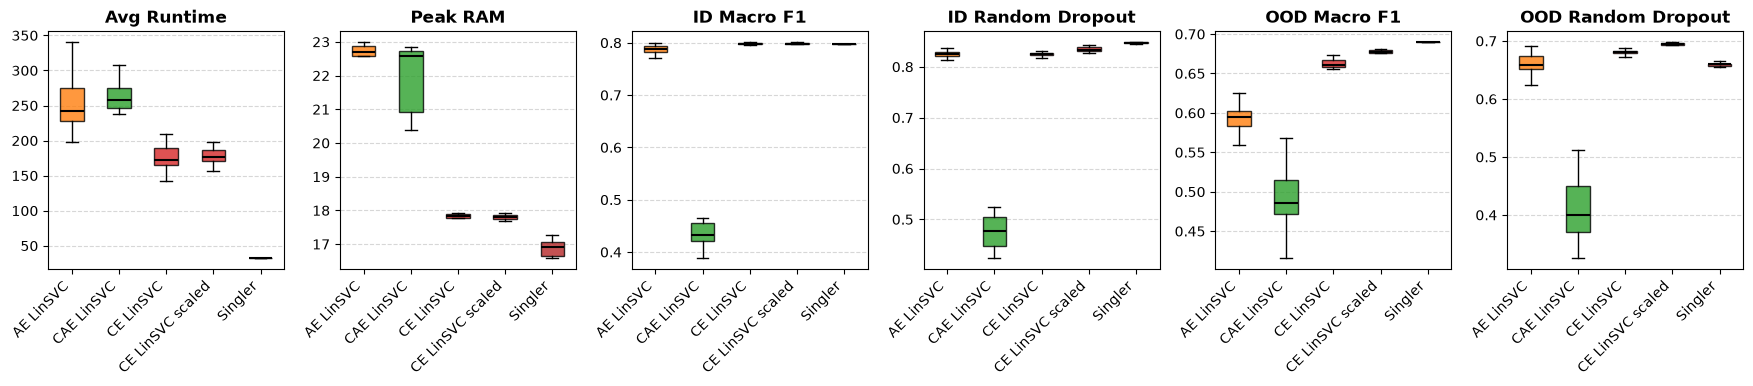

In [14]:
# temporary only with linsvc; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    if 'custom_ensemble_linsvc' in csv_path:
        df_linsvc = pd.read_csv('../training/results/new2/linearsvc/combined_result.csv', header=[0, 1, 2, 3], index_col=0)
        df_linsvc = df_linsvc.iloc[:10]
        linsvc_values = df_linsvc[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
        final_values = []
        for i in range(len(values)):
            final_values.append(values[i] + linsvc_values[i])
        data_for_boxplot.append(final_values)
    else:
        data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'Out-of-Distribution']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ae_linsvc_csv_file = '../training/results/new2/autoencoder_linsvc/combined_results.csv'
cae_linsvc_csv_file = '../training/results/new2/conditional_autoencoder_linsvc/combined_results.csv'
ce_linsvc_csv_file = '../training/results/new2/custom_ensemble_linsvc/combined_result.csv'
ce_linsvc_scaled_csv_file = '../training/results/new2/custom_ensemble_linsvc_scaled/combined_result.csv'

singler_csv_file = '../training/results/new2/singler/combined_result.csv'

subplot_titles = ['Avg Runtime', 'Peak RAM', 'ID Macro F1', 'ID Random Dropout', 'OOD Macro F1', 'OOD Random Dropout']

runs_model2 = extract_table_metrics_from_csv(ae_linsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(cae_linsvc_csv_file)
runs_model4 = extract_table_metrics_from_csv(ce_linsvc_csv_file)
runs_model5 = extract_table_metrics_from_csv(ce_linsvc_scaled_csv_file)

runs_model6 = extract_table_metrics_from_csv(singler_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['AE LinSVC', 'CAE LinSVC', 'CE LinSVC', 'CE LinSVC scaled', 'Singler']
colors = ['#ff7f0e', '#2ca02c', '#d62728', '#d42728', '#b62728']

# Erstelle ein 2x4 Grid mit unabhängigen Y-Achsen (sharey=False)
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), sharey=False)
axes = axes.flatten()  # Macht aus dem 2D-Array der Axes ein 1D-Array für leichteres Iterieren

for i, metric in enumerate(subplot_titles):
    ax = axes[i]
    
    # Die Daten der 4 Modelle für genau diesen einen Zelltyp zusammenstellen
    metric_data = [
        runs_model2[i],
        runs_model3[i],
        runs_model4[i],
        runs_model5[i],
        runs_model6[i]
    ]
    
    # Boxplot für diesen Zelltyp zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben aus der Liste anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        
    # Mediane schwarz markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Subplot-Design
    ax.set_title(subplot_titles[i], fontsize=12, weight='bold')
    
    # Beschriftung der X-Achse (Modellnamen um 45 Grad gedreht für Platz)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    
    # Y-Achse intelligent limitieren (Maximal 1.05, Minimum passt sich den Daten an)
    if "F1" in metric or "Dropout" in metric:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Globale Titel und Achsenbeschriftung
#fig.suptitle('Overview of Performance of Reference Models over 10 Runs', fontsize=18, weight='bold')
#fig.text(0.01, 0.5, 'F1-Score', va='center', rotation='vertical', fontsize=14, weight='bold')

# Layout bereinigen
plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

plt.savefig('figures/ae_cae_ce_scaled_comparison_table_metrics_box_plot.png')
plt.show()

## Feature Importance Dropout